## Using tools and tool-calling / Annotated(LangGraph stores states for conversation history automatically)

In [1]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage
from langchain_core.messages import ToolMessage
from langchain_core.messages import SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [2]:
load_dotenv()

True

In [3]:
MODEL = "gpt-5-mini"

In [4]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [5]:
@tool 
def add(a:int, b:int) -> int:
    """
    Tool function that returns an integer by adding param a and b
    """

    return a + b

@tool
def subtract(a:int, b:int) -> int:
    """
    Tool function that returns an integer by subtracting param a and b
    """

    return a - b

@tool
def multiply(a:int, b:int) -> int:
    """
    Tool function that returns an integer by multiplying param a and b
    """

    return a * b

@tool
def divide(a:int, b:int) -> int:
    """
    Tool function that returns an integer by dividing param a and b
    """

    if a < b:
        raise ValueError("A must be greater than or equal to B")

    return a / b

In [6]:
tools = [add, subtract, multiply, divide]
llm = ChatOpenAI(model=MODEL).bind_tools(tools)

In [7]:
def call_llm(state: AgentState) -> AgentState:
    """ 
    This is a node calling LLM responses
    """
    system_msg = SystemMessage(content="You are a helpful assistant answering user queries")
    
    response = llm.invoke([system_msg] + state["messages"])
    print("AI: ", response.content)
    return {
        "messages": [response]
   }

In [8]:
def should_continue(state: AgentState):
    """
    Conditional node that decides whether to continue or end the tool calling
    """
    messages = state["messages"]
    last_msg = messages[-1]

    if not last_msg.tool_calls:
        return "end"
    else: 
        return "continue"

In [9]:
graph = StateGraph(AgentState)

graph.add_node("llm_agent", call_llm)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.add_edge(START, "llm_agent")
graph.add_conditional_edges(
    "llm_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    }
)
graph.add_edge("tools","llm_agent")

app = graph.compile()

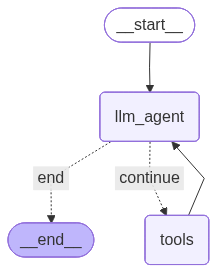

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple): 
            print(message)
        else: 
            message.pretty_print()

In [14]:
inputs = {
    "messages": [
        ("user", "Add 40 + 12 and then multiply the result by 6. Also tell me a joke.")
    ]
}

print_stream(app.stream(inputs, stream_mode="values"))

STREAM <generator object Pregel.stream at 0xc49fcf990>
================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6. Also tell me a joke.
AI:  
================================== Ai Message ==================================
Tool Calls:
  add (call_Bofv7kEAAsBAqNa2CdjcIeBw)
 Call ID: call_Bofv7kEAAsBAqNa2CdjcIeBw
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: add

52
AI:  
================================== Ai Message ==================================
Tool Calls:
  multiply (call_bwHEj7iibZsZOydyH1tQVFHz)
 Call ID: call_bwHEj7iibZsZOydyH1tQVFHz
  Args:
    a: 52
    b: 6
================================= Tool Message =================================
Name: multiply

312
AI:  40 + 12 = 52; 52 × 6 = 312.

Joke: Why did the math book look sad? Because it had too many problems.
================================== Ai Message =================================